# Tarea para el Hogar 05 — versión Python

Adaptación de `z494_python.ipynb` a la lógica de `z495_GustavoPasquini.ipynb`. La carga del dataset y la generación de la clase ternaria permanecen sin cambios.

# Librerías

In [1]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())



cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
import lightgbm as lgb
import yaml

In [3]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys

# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent

# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria


# URLs

In [4]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)
BASE_DATA_URL = os.path.join('/mnt/', 'e')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')

DATA_URL = os.path.join(BASE_URL, "DATA")
DATASETS_URL = os.path.join(DATA_URL, "DATASETS")
EXP_URL = os.path.join(DATA_URL, "EXP")
dataset_url = os.path.join(DATASETS_URL, "competencia_01_crudo.csv")
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
DATA_LAGS_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lags.csv')
DATA_LAGS_FRAC_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lf_k6_perdida4.csv')



experiment_name = "LAG-008"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

os.makedirs(EXPERIMENT_URL, exist_ok=True)

In [5]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'competencia_01_ternaria_lags.csv',
 'competencia_01_ternaria_lf_k6_perdida4.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

# Constantes

In [6]:
SEED = 230047

In [7]:
PARAM = {
    "experimento": experiment_name,
    "semilla_primigenia": SEED,
    "training_pct": 70,
    "train": [202104],
    "train_final": [202104],
    "future": [202106],
    "cortes": list(range(9_000, 15_001, 500)),
    "trainingstrategy": {"undersampling": 0.1},
    "hyperparametertuning": {
        "iteraciones": 200,
        "n_startup_trials": 50,
        "xval_folds" : 3
    },
    "lgbm": {
        "param_fijos": {
            "boosting": "gbdt",
            "objective": "binary",
            # "metric": "auc",
            "metric": "average_precision",
            "feature_pre_filter": False,
            "first_metric_only": False,
            "boost_from_average": True,
            "force_row_wise": True,
            "deterministic": True,
            "verbosity": -100,
            "seed": SEED,
            "max_depth": -1,
            "min_gain_to_split": 0.0,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
            "max_bin": 31,
            "bagging_fraction": 1.0,
            "pos_bagging_fraction": 1.0,
            "neg_bagging_fraction": 1.0,
            "is_unbalance": False,
            "scale_pos_weight": 1.0,
            "drop_rate": 0.1,
            "max_drop": 50,
            "skip_drop": 0.5,
            "extra_trees": False,
            "early_stopping": 0,
            "min_data_in_leaf": 0,
            "feature_fraction": 0.50,
            # "learning_rate": 0.005,
  
        }
    },
    "out": {"lgbm": {}},
}


# Lectura del dataset

In [8]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    DATA_LAGS_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [9]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares_delta1,Visa_fultimo_cierre_delta1,Visa_mpagado_delta1,Visa_mpagospesos_delta1,Visa_mpagosdolares_delta1,Visa_fechaalta_delta1,Visa_mconsumototal_delta1,Visa_cconsumos_delta1,Visa_cadelantosefectivo_delta1,Visa_mpagominimo_delta1
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12159854,202104,1,0,0,56,135,1622.57,27663.64,931.59,...,0.0,1.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0
2,12159854,202105,1,0,0,56,136,1987.98,28738.37,934.07,...,0.0,3.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0
3,12159854,202106,1,0,0,56,137,2580.75,29494.76,915.19,...,0.0,-5.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0
4,12159854,202107,1,0,0,56,138,2686.85,29431.10,688.94,...,0.0,3.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0


In [10]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
BAJA+1,1019,964,1143,874,1103,0
BAJA+2,960,1139,870,1098,0,0
NA,0,0,0,0,163245,164647
continua,160921,161181,161755,162142,0,0


In [11]:
df_completo = df.copy()

# Optimización de hiperparámetros

Se ejecutan dos BO consecutivas, cada una con 300 trials totales, incluidos 50 de inicialización.

## Preprocesamiento

In [12]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# Partición estratificada 70/30, equivalente a fold 1 y fold 2 en z495.
indices_fold_1, indices_fold_2 = train_test_split(
    np.arange(len(dataset_train_cpu)),
    train_size=PARAM["training_pct"] / 100,
    stratify=dataset_train_cpu["ternaria"],
    random_state=PARAM["semilla_primigenia"],
)

dataset_train_cpu["fold"] = np.int8(2)
dataset_train_cpu.loc[indices_fold_1, "fold"] = np.int8(1)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    dataset_train_cpu["fold"].eq(1)
    & (
        (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
        | dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    )
).astype(np.int8)

columnas_excluidas = {
    "ternaria",
    "ternaria_lag1",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "cprestamos_personales_lag1",
    "cprestamos_personales_delta1",
    "mprestamos_personales",
    "mprestamos_personales_lag1",
    "mprestamos_personales_delta1"
}

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in columnas_excluidas
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

# Replica literalmente z495: validation contiene todas las filas con training == 0.
mask_validation = dataset_train_cpu["training"].eq(0)
X_validate_bo = dataset_train_cpu.loc[mask_validation, campos_buenos]
y_validate_bo = dataset_train_cpu.loc[mask_validation, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

dvalidate = lgb.Dataset(
    data=X_validate_bo,
    label=y_validate_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para training:", len(X_train_bo))
print("Filas para validation:", len(X_validate_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["fold", "ternaria", "training"]).size()

Filas para training: 12698
Filas para validation: 150586
Columnas: 452


fold  ternaria  training
1     BAJA+1    1              675
      BAJA+2    1              797
      continua  0           101600
                1            11226
2     BAJA+1    0              289
      BAJA+2    0              342
      continua  0            48355
dtype: int64

## Función objetivo: Average Precision sobre validation

In [13]:
def estimar_auc_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    # En Python conviene pasar el número de árboles por su argumento dedicado.
    num_boost_round = int(parametros_completos.pop("num_iterations"))

    resultados_cv = lgb.cv(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        nfold=PARAM["hyperparametertuning"]["xval_folds"],
        stratified=True,
        shuffle=True,
        seed=PARAM["semilla_primigenia"],
    )

    clave_auc = next(
        clave for clave in resultados_cv
        if clave.endswith("auc-mean")
    )

    # Sin early stopping, equivale al score al finalizar num_iterations.
    return float(resultados_cv[clave_auc][-1])

In [14]:
def estimar_ap_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(parametros_completos.pop("num_iterations"))

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        valid_sets=[dvalidate],
        valid_names=["val"],
    )

    return float(modelo.best_score["val"]["average_precision"])

In [15]:
ganancia_validate_bo = np.where(
    dataset_train_cpu.loc[mask_validation, "ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)


def estimar_ganancia_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(
        parametros_completos.pop("num_iterations")
    )

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
    )

    prediccion = modelo.predict(X_validate_bo)
    orden = np.argsort(-prediccion)

    ganancia_acumulada = np.cumsum(
        ganancia_validate_bo[orden]
    )

    return float(ganancia_acumulada.max())

In [16]:
rangos_bo = {'num_iterations': (700, 4000),
 'num_leaves': (16, 256),
 'feature_fraction': (0.3, 0.75),
 'min_sum_hessian_in_leaf': (0.0001, 0.1),
 'learning_rate': (0.002, 0.02),
 'min_data_in_leaf': (0, 500)}

def objective(trial):
    parametros_variables = {
        "num_iterations": trial.suggest_int(
            "num_iterations", *rangos_bo["num_iterations"]
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", *rangos_bo["num_leaves"], log=True
        ),
        "feature_fraction": trial.suggest_float(
            "feature_fraction", *rangos_bo["feature_fraction"]
        ),
        "min_sum_hessian_in_leaf": trial.suggest_float(
            "min_sum_hessian_in_leaf",
            *rangos_bo["min_sum_hessian_in_leaf"],
            log=True,
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", *rangos_bo["learning_rate"], log=True
        ),
        "min_data_in_leaf": trial.suggest_int(
            "min_data_in_leaf",
            *rangos_bo["min_data_in_leaf"],
            log=rangos_bo["min_data_in_leaf"][0] > 0,
        ),
    }
    if "scale_pos_weight" in rangos_bo:
        parametros_variables["scale_pos_weight"] = trial.suggest_float(
            "scale_pos_weight", *rangos_bo["scale_pos_weight"]
        )
    return estimar_ap_lightgbm(parametros_variables)
    # return estimar_auc_lightgbm(parametros_variables)
    # return estimar_ganancia_lightgbm(parametros_variables)


## Estudio Optuna y reanudación

In [17]:
puntos_iniciales_bo = [{'num_iterations': 2505,
  'num_leaves': 61,
  'feature_fraction': 0.570791092426478,
  'min_sum_hessian_in_leaf': 0.00672743877633617,
  'learning_rate': 0.00201824142135213,
  'min_data_in_leaf': 184},
 {'num_iterations': 1058,
  'num_leaves': 38,
  'feature_fraction': 0.5,
  'min_sum_hessian_in_leaf': 0.006770759,
  'learning_rate': 0.005,
  'min_data_in_leaf': 0},
 {'num_iterations': 1247,
  'num_leaves': 34,
  'feature_fraction': 0.5,
  'min_sum_hessian_in_leaf': 0.03939008,
  'learning_rate': 0.005,
  'min_data_in_leaf': 0},
 {'num_iterations': 3359,
  'num_leaves': 58,
  'feature_fraction': 0.5,
  'min_sum_hessian_in_leaf': 0.082382575493708,
  'learning_rate': 0.005,
  'min_data_in_leaf': 0}]

n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

for punto in puntos_iniciales_bo:
    study.enqueue_trial(punto, skip_if_exists=True)


/tmp/ipykernel_70678/3589297011.py:29: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-09-23 22:49:29,514] A new study created in RDB with name: LAG-008


In [18]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-23 22:49:59,585] Trial 0 finished with value: 0.13038871917859474 and parameters: {'num_iterations': 2505, 'num_leaves': 61, 'feature_fraction': 0.570791092426478, 'min_sum_hessian_in_leaf': 0.00672743877633617, 'learning_rate': 0.00201824142135213, 'min_data_in_leaf': 184}. Best is trial 0 with value: 0.13038871917859474.
[I 2026-09-23 22:50:07,778] Trial 1 finished with value: 0.12843745498928702 and parameters: {'num_iterations': 1058, 'num_leaves': 38, 'feature_fraction': 0.5, 'min_sum_hessian_in_leaf': 0.006770759, 'learning_rate': 0.005, 'min_data_in_leaf': 0}. Best is trial 0 with value: 0.13038871917859474.
[I 2026-09-23 22:50:16,806] Trial 2 finished with value: 0.1250159006704722 and parameters: {'num_iterations': 1247, 'num_leaves': 34, 'feature_fraction': 0.5, 'min_sum_hessian_in_leaf': 0.03939008, 'learning_rate': 0.005, 'min_data_in_leaf': 0}. Best is trial 0 with value: 0.13038871917859474.
[I 2026-09-23 22:50:45,580] Trial 3 finished with value: 0.11716126150

## Resultados de la optimización

In [19]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 1345, 'num_leaves': 43, 'feature_fraction': 0.75, 'min_sum_hessian_in_leaf': 0.00010000000000000009, 'learning_rate': 0.0027630652615671675, 'min_data_in_leaf': 52}
Mejor Average Precision: 0.13669331697916912


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_data_in_leaf,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,system_attrs_fixed_params,system_attrs_gp:relative_params:0,state,iter
0,153,0.136693,2026-09-23 23:34:09.920002,2026-09-23 23:34:19.505303,0 days 00:00:09.585301,0.75,0.002763,52,0.0001,1345,43,NaN,"{""feature_fraction"": 0.75, ""learning_rate"": 0....",COMPLETE,154
1,149,0.136059,2026-09-23 23:33:29.669226,2026-09-23 23:33:40.492139,0 days 00:00:10.822913,0.75,0.002710,69,0.0001,1460,51,NaN,"{""feature_fraction"": 0.75, ""learning_rate"": 0....",COMPLETE,150
2,144,0.135984,2026-09-23 23:32:33.588158,2026-09-23 23:32:45.941678,0 days 00:00:12.353520,0.75,0.002304,73,0.0001,1805,44,NaN,"{""feature_fraction"": 0.75, ""learning_rate"": 0....",COMPLETE,145
3,148,0.135897,2026-09-23 23:33:17.558816,2026-09-23 23:33:29.636078,0 days 00:00:12.077262,0.75,0.002712,60,0.0001,1632,48,NaN,"{""feature_fraction"": 0.75, ""learning_rate"": 0....",COMPLETE,149
4,145,0.135895,2026-09-23 23:32:45.976264,2026-09-23 23:32:56.109178,0 days 00:00:10.132914,0.75,0.002442,53,0.0001,1416,53,NaN,"{""feature_fraction"": 0.75, ""learning_rate"": 0....",COMPLETE,146


In [20]:
plot_optimization_history(study)

In [21]:
plot_slice(study)

In [22]:
plot_contour(study)

# Producción

## Final training sobre todos los datos de 202104

In [23]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
BAJA+1         964
BAJA+2        1139
continua    161181
dtype: int64

In [24]:
dataset_final_cpu.clase01.value_counts()

clase01
0    161181
1      2103
Name: count, dtype: int64

In [25]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final["min_data_in_leaf"] = round(
    param_final["min_data_in_leaf"] / PARAM["trainingstrategy"]["undersampling"]
)
param_final

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'average_precision',
 'feature_pre_filter': False,
 'first_metric_only': False,
 'boost_from_average': True,
 'force_row_wise': True,
 'deterministic': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'early_stopping': 0,
 'min_data_in_leaf': 520,
 'feature_fraction': 0.75,
 'num_leaves': 43,
 'min_sum_hessian_in_leaf': 0.00010000000000000009,
 'learning_rate': 0.0027630652615671675}

In [26]:
print(campos_buenos)

['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones', 'mactivos_margen', 'mpasivos_margen', 'cproductos', 'tcuentas', 'ccuenta_corriente', 'mcuenta_corriente_adicional', 'mcuenta_corriente', 'ccaja_ahorro', 'mcaja_ahorro', 'mcaja_ahorro_adicional', 'mcaja_ahorro_dolares', 'cdescubierto_preacordado', 'mcuentas_saldo', 'ctarjeta_debito', 'ctarjeta_debito_transacciones', 'mautoservicio', 'ctarjeta_visa', 'ctarjeta_visa_transacciones', 'mtarjeta_visa_consumo', 'ctarjeta_master', 'ctarjeta_master_transacciones', 'mtarjeta_master_consumo', 'cprestamos_prendarios', 'mprestamos_prendarios', 'cprestamos_hipotecarios', 'mprestamos_hipotecarios', 'cplazo_fijo', 'mplazo_fijo_dolares', 'mplazo_fijo_pesos', 'cinversion1', 'minversion1_pesos', 'minversion1_dolares', 'cinversion2', 'minversion2', 'cseguro_vida', 'cseguro_auto', 'cseguro_vivienda', 'cseguro_accidentes_personales', 'cca

In [27]:
dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

## Importancia de variables y modelo

In [28]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
217,ctrx_quarter,0.286197,0.083389,0.017773
219,ctrx_quarter_lag1,0.065513,0.012531,0.005417
266,mcuentas_saldo,0.055769,0.024734,0.019880
280,mpayroll,0.034801,0.083387,0.015259
170,cpayroll_trx,0.031913,0.057693,0.013790
176,cproductos,0.023517,0.032123,0.021898
235,mcaja_ahorro,0.018031,0.011075,0.012126
85,Visa_mpagominimo,0.017360,0.021871,0.016658
177,cproductos_delta1,0.016494,0.019319,0.013117
289,mrentabilidad_annual_lag1,0.016310,0.019676,0.026111


## Scoring sobre 202106

In [29]:
df_completo.shape

(983061, 460)

In [30]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.001831
1,12159858,202106,continua,0.002118
2,12160484,202106,continua,0.003053
3,12160591,202106,continua,0.001075
4,12160747,202106,continua,0.007139


## Curva de ganancia

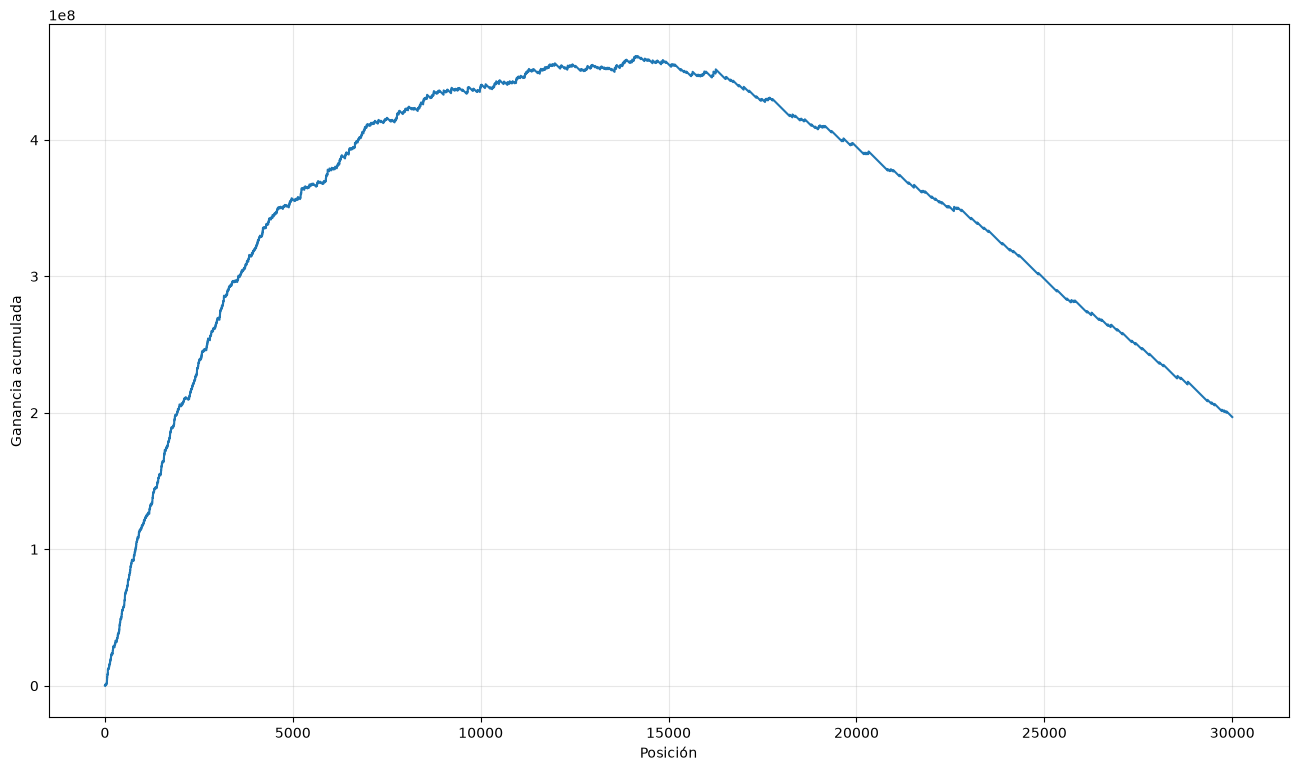

In [31]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

## Ganancia bajo distintos cortes

In [32]:
resultados_cortes = []

for envios in PARAM["cortes"]:
    ganancia = tb_prediccion.iloc[:envios]["gan"].sum()
    resultados_cortes.append({
        "envios": envios,
        "ganancia": ganancia,
    })
    print(f"{envios}	{ganancia:.0f}")

resultados_cortes_df = pd.DataFrame(resultados_cortes)
resultados_cortes_df

9000	433400000
9500	436150000
10000	438900000
10500	442750000
11000	445500000
11500	449350000
12000	455400000
12500	453750000
13000	454300000
13500	451550000
14000	457600000
14500	458150000
15000	455400000


,envios,ganancia
0,9000,433400000
1,9500,436150000
2,10000,438900000
3,10500,442750000
4,11000,445500000
5,11500,449350000
6,12000,455400000
7,12500,453750000
8,13000,454300000
9,13500,451550000


In [33]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

## Segunda BO: LAG-009

In [34]:
experiment_name = "LAG-009"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)
os.makedirs(EXPERIMENT_URL, exist_ok=True)
PARAM["experimento"] = experiment_name
PARAM["out"]["lgbm"] = {}

rangos_bo = {'num_iterations': (400, 2000),
 'num_leaves': (256, 2048),
 'feature_fraction': (0.1, 0.35),
 'min_sum_hessian_in_leaf': (0.0001, 0.1),
 'learning_rate': (0.005, 0.025),
 'min_data_in_leaf': (100, 1000),
 'scale_pos_weight': (0.5, 1.0)}

puntos_iniciales_bo = [{'num_iterations': 930,
  'num_leaves': 1684,
  'feature_fraction': 0.154,
  'min_sum_hessian_in_leaf': 0.001,
  'learning_rate': 0.02,
  'min_data_in_leaf': 460,
  'scale_pos_weight': 0.5},
 {'num_iterations': 936,
  'num_leaves': 1545,
  'feature_fraction': 0.3408123,
  'min_sum_hessian_in_leaf': 0.001,
  'learning_rate': 0.006107147,
  'min_data_in_leaf': 263,
  'scale_pos_weight': 1.0},
 {'num_iterations': 600,
  'num_leaves': 1684,
  'feature_fraction': 0.1541961,
  'min_sum_hessian_in_leaf': 0.001,
  'learning_rate': 0.02,
  'min_data_in_leaf': 1000,
  'scale_pos_weight': 0.5}]

n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

for punto in puntos_iniciales_bo:
    study.enqueue_trial(punto, skip_if_exists=True)


/tmp/ipykernel_70678/34903294.py:40: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-09-23 23:44:50,402] A new study created in RDB with name: LAG-009


In [35]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-23 23:44:55,543] Trial 0 finished with value: 0.11601345974871068 and parameters: {'num_iterations': 930, 'num_leaves': 1684, 'feature_fraction': 0.154, 'min_sum_hessian_in_leaf': 0.001, 'learning_rate': 0.02, 'min_data_in_leaf': 460, 'scale_pos_weight': 0.5}. Best is trial 0 with value: 0.11601345974871068.
[I 2026-09-23 23:45:01,897] Trial 1 finished with value: 0.1236460942931976 and parameters: {'num_iterations': 936, 'num_leaves': 1545, 'feature_fraction': 0.3408123, 'min_sum_hessian_in_leaf': 0.001, 'learning_rate': 0.006107147, 'min_data_in_leaf': 263, 'scale_pos_weight': 1.0}. Best is trial 1 with value: 0.1236460942931976.
[I 2026-09-23 23:45:05,033] Trial 2 finished with value: 0.09595473544377366 and parameters: {'num_iterations': 600, 'num_leaves': 1684, 'feature_fraction': 0.1541961, 'min_sum_hessian_in_leaf': 0.001, 'learning_rate': 0.02, 'min_data_in_leaf': 1000, 'scale_pos_weight': 0.5}. Best is trial 1 with value: 0.1236460942931976.
[I 2026-09-23 23:45:08,3

In [36]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 454, 'num_leaves': 256, 'feature_fraction': 0.264156247389931, 'min_sum_hessian_in_leaf': 0.1, 'learning_rate': 0.018571119919268193, 'min_data_in_leaf': 181, 'scale_pos_weight': 0.5}
Mejor Average Precision: 0.1324890378631483


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_data_in_leaf,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,params_scale_pos_weight,system_attrs_fixed_params,system_attrs_gp:relative_params:0,state,iter
0,83,0.132489,2026-09-23 23:55:42.047329,2026-09-23 23:55:45.773584,0 days 00:00:03.726255,0.264156,0.018571,181,0.1000,454,256,0.5,NaN,"{""feature_fraction"": 0.264156247389931, ""learn...",COMPLETE,84
1,111,0.132212,2026-09-23 23:59:31.714177,2026-09-23 23:59:40.565343,0 days 00:00:08.851166,0.350000,0.006755,168,0.0001,1067,2048,0.5,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,112
2,86,0.131996,2026-09-23 23:55:53.148743,2026-09-23 23:55:56.602724,0 days 00:00:03.453981,0.239049,0.015280,137,0.1000,400,256,0.5,NaN,"{""feature_fraction"": 0.23904901858297337, ""lea...",COMPLETE,87
3,115,0.131915,2026-09-24 00:00:04.312343,2026-09-24 00:00:07.997103,0 days 00:00:03.684760,0.350000,0.015312,181,0.1000,400,256,0.5,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,116
4,145,0.131442,2026-09-24 00:03:12.144774,2026-09-24 00:03:25.316852,0 days 00:00:13.172078,0.350000,0.005000,174,0.1000,1673,2048,1.0,NaN,"{""feature_fraction"": 0.35, ""learning_rate"": 0....",COMPLETE,146


## Producción: LAG-009

In [37]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final["min_data_in_leaf"] = round(
    param_final["min_data_in_leaf"] / PARAM["trainingstrategy"]["undersampling"]
)
param_final

dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

In [38]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
221,ctrx_quarter,0.110696,0.024022,0.014105
223,ctrx_quarter_lag1,0.071475,0.014628,0.011296
262,mcuentas_saldo,0.044818,0.013439,0.013372
177,cpayroll_trx,0.031858,0.014399,0.003389
274,mpasivos_margen,0.031718,0.008529,0.009434
239,mcaja_ahorro,0.031087,0.009245,0.011846
183,cproductos,0.024385,0.018172,0.009312
277,mpayroll,0.021390,0.018277,0.007266
292,mtarjeta_visa_consumo,0.019167,0.009578,0.011144
276,mpasivos_margen_lag1,0.017877,0.006289,0.009281


In [39]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.000194
1,12159858,202106,continua,0.004010
2,12160484,202106,continua,0.000800
3,12160591,202106,continua,0.000250
4,12160747,202106,continua,0.003995


In [40]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)